# Chapter 3: Unsupervised Learning and Dimensionality
## Practical: PCA and K-Means with Scikit-Learn

### Setup: Generate Synthetic Data (Two Moons)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Generate data: two interleaving half circles
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Data shape: {X.shape}")
print(f"True labels: {np.unique(y_true)}")

Data shape: (300, 2)
True labels: [0 1]


### PCA for Visualisation

Explained variance ratio: [0.7229774 0.2770226]
Total variance explained by 2 components: 1.000


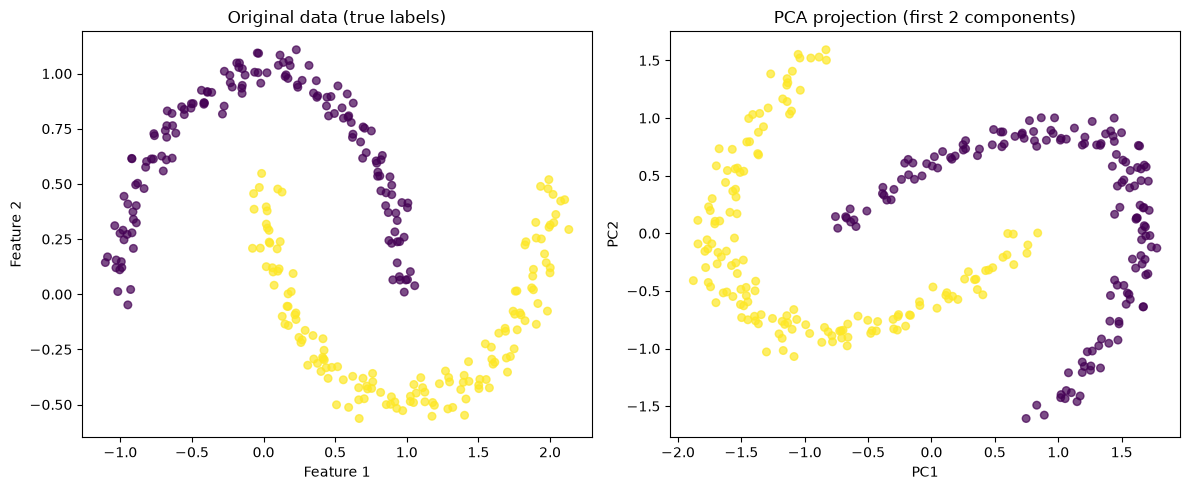

In [2]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.3f}")

# Plot original and PCA projection
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.7)
axes[0].set_title("Original data (true labels)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.7)
axes[1].set_title("PCA projection (first 2 components)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

### K-Means Clustering

C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Adjusted Rand Index: 0.470


C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\user\miniconda3\envs\david\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMe

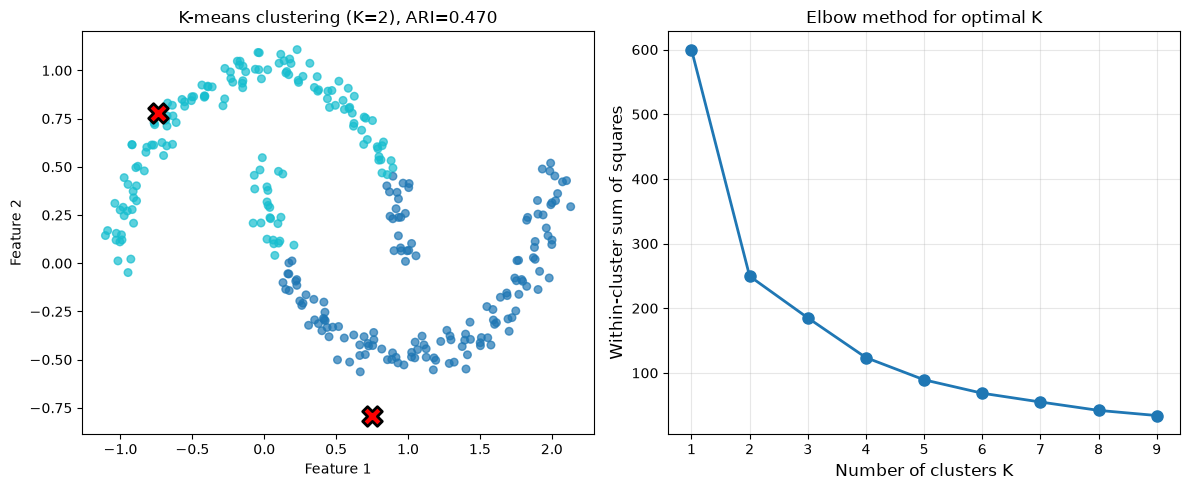

In [3]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(y_true, y_kmeans)
print(f"Adjusted Rand Index: {ari:.3f}")

# Visualise clustering results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='tab10', s=30, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                marker='X', s=200, c='red', edgecolors='black', linewidths=2)
axes[0].set_title(f"K-means clustering (K=2), ARI={ari:.3f}")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Elbow method
distortions = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    distortions.append(km.inertia_)

axes[1].plot(K_range, distortions, 'o-', markersize=8, linewidth=2)
axes[1].set_xlabel('Number of clusters K', fontsize=12)
axes[1].set_ylabel('Within-cluster sum of squares', fontsize=12)
axes[1].set_title('Elbow method for optimal K')
axes[1].set_xticks(K_range)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Extension: PCA for Denoising

AttributeError: 'Axes' object has no attribute 'set_axis_equal'

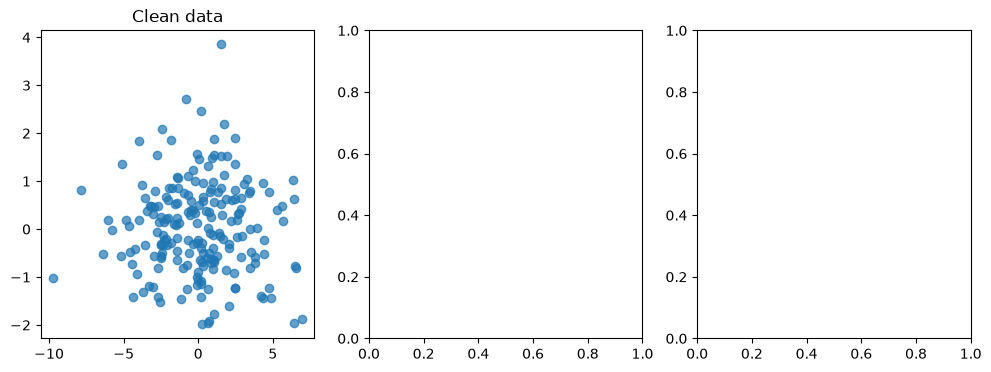

In [5]:
# Create elongated Gaussian with noise
np.random.seed(42)
X_clean = np.random.randn(200, 2) @ np.diag([3.0, 1.0])
noise = 0.5 * np.random.randn(200, 2)
X_noisy = X_clean + noise

# Apply PCA with 1 component
pca_denoise = PCA(n_components=1)
X_pca_1 = pca_denoise.fit_transform(X_noisy)
X_denoised = pca_denoise.inverse_transform(X_pca_1)

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(X_clean[:, 0], X_clean[:, 1], alpha=0.7)
axes[0].set_title("Clean data")
axes[0].set_axis_equal()

axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], alpha=0.7)
axes[1].set_title("Noisy data")
axes[1].set_axis_equal()

axes[2].scatter(X_denoised[:, 0], X_denoised[:, 1], alpha=0.7)
axes[2].set_title("Denoised (PCA, k=1)")
axes[2].set_axis_equal()

plt.tight_layout()
plt.show()

### Observations

- PCA captures most variance but cannot separate the moons (nonlinear structure).
- K-means finds two clusters that roughly correspond to the two moons.
- The elbow method shows a clear elbow at K=2 (phase transition).
- PCA denoising projects data onto the principal direction, removing orthogonal noise.